# 🌸 প্রথম ML অ্যাপ: আইরিস শ্রেণীবিভাগ

**স্বাগতম!** আজ আমরা একটি বাস্তব ML প্রজেক্ট করবো — **Iris ফুল শ্রেণীবিভাগ**।

এই প্রজেক্টটি ML শিক্ষার **"Hello World"** 🌍 — মানে এটাই প্রথম প্রোগ্রাম যা সবাই শেখে!

**আজকের লক্ষ্য:** একটি ML মডেল তৈরি করা যা ফুলের বৈশিষ্ট্য দেখে বলে দেবে — "এটা কোন প্রজাতির ফুল?"

**আজকে আমরা ৭টি ধাপে কাজ করবো:**
1. 📖 গল্প: তিন বোন ফুল
2. 📦 ডেটা লোড
3. 🔍 ডেটা এক্সপ্লোর
4. ✂️ ট্রেন-টেস্ট স্প্লিট
5. 🤖 KNN মডেল তৈরি
6. 📐 নির্ভুলতা মাপা
7. 🧪 নিজে পরীক্ষা করা

---
## 📖 গল্প: তিন বোন ফুল

এক বাগানে তিন বোন ফুল থাকে। তাদের মধ্যে মিল আছে, আবার অমিলও আছে:

| বোন | বৈজ্ঞানিক নাম | বিশেষত্ব |
|-----|--------------|----------|
| 👩‍🦰 **সেতোসা** (Setosa) | *Iris setosa* | ছোট পাপড়ি (০.২-০.৫ cm), খুব আলাদা দেখতে |
| 👩 **ভার্সিকলার** (Versicolor) | *Iris versicolor* | মাঝারি পাপড়ি (১.০-১.৮ cm), নীলচে-বেগুনি |
| 👩‍🦱 **ভার্জিনিকা** (Virginica) | *Iris virginica* | বড় পাপড়ি (১.৪-২.৫ cm), লম্বা, মোটা |

### কীভাবে তুমি এদের চিনবে?

ধরো, তুমি বাগানে দাঁড়িয়ে আছো। তুমি একটি ফুল দেখতে পেলে।

**ABCD ধাপ — ফুল চেনার:**

> **A** — ফুলের পাপড়ি দেখো (petal length + petal width) 📏
> **B** — সেপাল দেখো (sepal length + sepal width) 📐
> **C** — আগে দেখা ফুলের সাথে তুলনা করো 🧠
> **D** — সিদ্ধান্ত নাও: "এই ফুলটা X!" ✅

কম্পিউটার ঠিক এভাবেই কাজ করে! শুধু পার্থক্য হলো — কম্পিউটার সংখ্যা (measurements) দেখে আর মানুষ চোখে দেখে।

### 📜 ইতিহাস
Iris ডেটাসেট তৈরি করেছিলেন **Ronald Fisher** (একজন বিখ্যাত পরিসংখ্যানবিদ) ১৯৩৬ সালে! প্রায় ১০০ বছর আগে! এখনো ML শেখার জন্য এটাই প্রথম ডেটাসেট! 🏆

---
## 📦 ধাপ ১: ডেটা লোড করা

প্রথমে আমরা sklearn থেকে Iris ডেটাসেট লোড করবো। এটা আগে থেকে sklearn-এর মধ্যে আছে — তাই আলাদাভাবে ডাউনলোড করতে হবে না!

In [1]:
# প্রয়োজনীয় লাইব্রেরি ইম্পোর্ট
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
print("📦 সব লাইব্রেরি ইম্পোর্টেড!")
print()

# আইরিস ডেটাসেট লোড
iris = load_iris()
print("🌸 **আইরিস ডেটাসেট**")
print("=" * 35)
print(f"📐 ডেটার মাত্রা (samples x features): {iris.data.shape}")
print(f"   → {iris.data.shape[0]} টি ফুলের নমুনা")
print(f"   → {iris.data.shape[1]} টি বৈশিষ্ট্য (features)")
print()
print(f"📋 ফিচারের নাম:")
for i, name in enumerate(iris.feature_names):
    print(f"   {i+1}. {name}")
print()
print(f"🏷️ লক্ষ্যের নাম (ফুলের প্রজাতি): {iris.target_names}")
print(f"   → 0 = {iris.target_names[0]}")
print(f"   → 1 = {iris.target_names[1]}")
print(f"   → 2 = {iris.target_names[2]}")

📦 সব লাইব্রেরি ইম্পোর্টেড!

🌸 **আইরিস ডেটাসেট**
📐 ডেটার মাত্রা (samples x features): (150, 4)
   → 150 টি ফুলের নমুনা
   → 4 টি বৈশিষ্ট্য (features)

📋 ফিচারের নাম:
   1. sepal length (cm)
   2. sepal width (cm)
   3. petal length (cm)
   4. petal width (cm)

🏷️ লক্ষ্যের নাম (ফুলের প্রজাতি): ['setosa' 'versicolor' 'virginica']
   → 0 = setosa
   → 1 = versicolor
   → 2 = virginica


---
## 🔍 ধাপ ২: ডেটা এক্সপ্লোর করা

ডেটা এক্সপ্লোর করা মানে **ডেটাকে জানা**। যেমন:
- কয়টি নমুনা আছে?
- প্রতিটি প্রজাতির কয়টি করে নমুনা আছে?
- ডেটার গড়, সর্বনিম্ন, সর্বোচ্চ মান কত?
- কোন বৈশিষ্ট্য দিয়ে ফুল আলাদা করা সহজ?

> **মনে রেখো:** "ডেটা জানলেই ML-এর অর্ধেক কাজ শেষ!" 🏆

In [2]:
# pandas DataFrame তৈরি করি — যাতে ডেটা সহজে দেখা যায়
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)
print("📋 **প্রথম 10টি নমুনা:**")
print(df.head(10))
print()
print("📊 **পরিসংখ্যান (describe):**")
print(df.describe())
print()
print("🔢 **প্রতিটি প্রজাতির সংখ্যা:**")
print(df['species'].value_counts())
print()
print("ℹ️ **ডেটা সম্পর্কে তথ্য:**")
print(df.info())

📋 **প্রথম 10টি নমুনা:**
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   
5                5.4               3.9                1.7               0.4   
6                4.6               3.4                1.4               0.3   
7                5.0               3.4                1.5               0.2   
8                4.4               2.9                1.4               0.2   
9                4.9               3.1                1.5               0.1   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  
5  setosa  
6  setosa  
7  setosa 

C:\Users\hp\AppData\Local\Temp\ipykernel_11092\1114087872.py:21: UserWarning: Glyph 2488 (\N{BENGALI LETTER SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_11092\1114087872.py:21: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_11092\1114087872.py:21: UserWarning: Glyph 2503 (\N{BENGALI VOWEL SIGN E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_11092\1114087872.py:21: UserWarning: Glyph 2472 (\N{BENGALI LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_11092\1114087872.py:21: UserWarning: Glyph 2509 (\N{BENGALI SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_11092\1114087872.py:21: UserWarning: Glyph 2463 (\N{BENGALI LETTER TTA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2488 (\N{BENGALI LETTER SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2434 (\N{BENGALI SIGN ANUSVARA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2454 (\N{BENGALI LETTER KHA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: Us

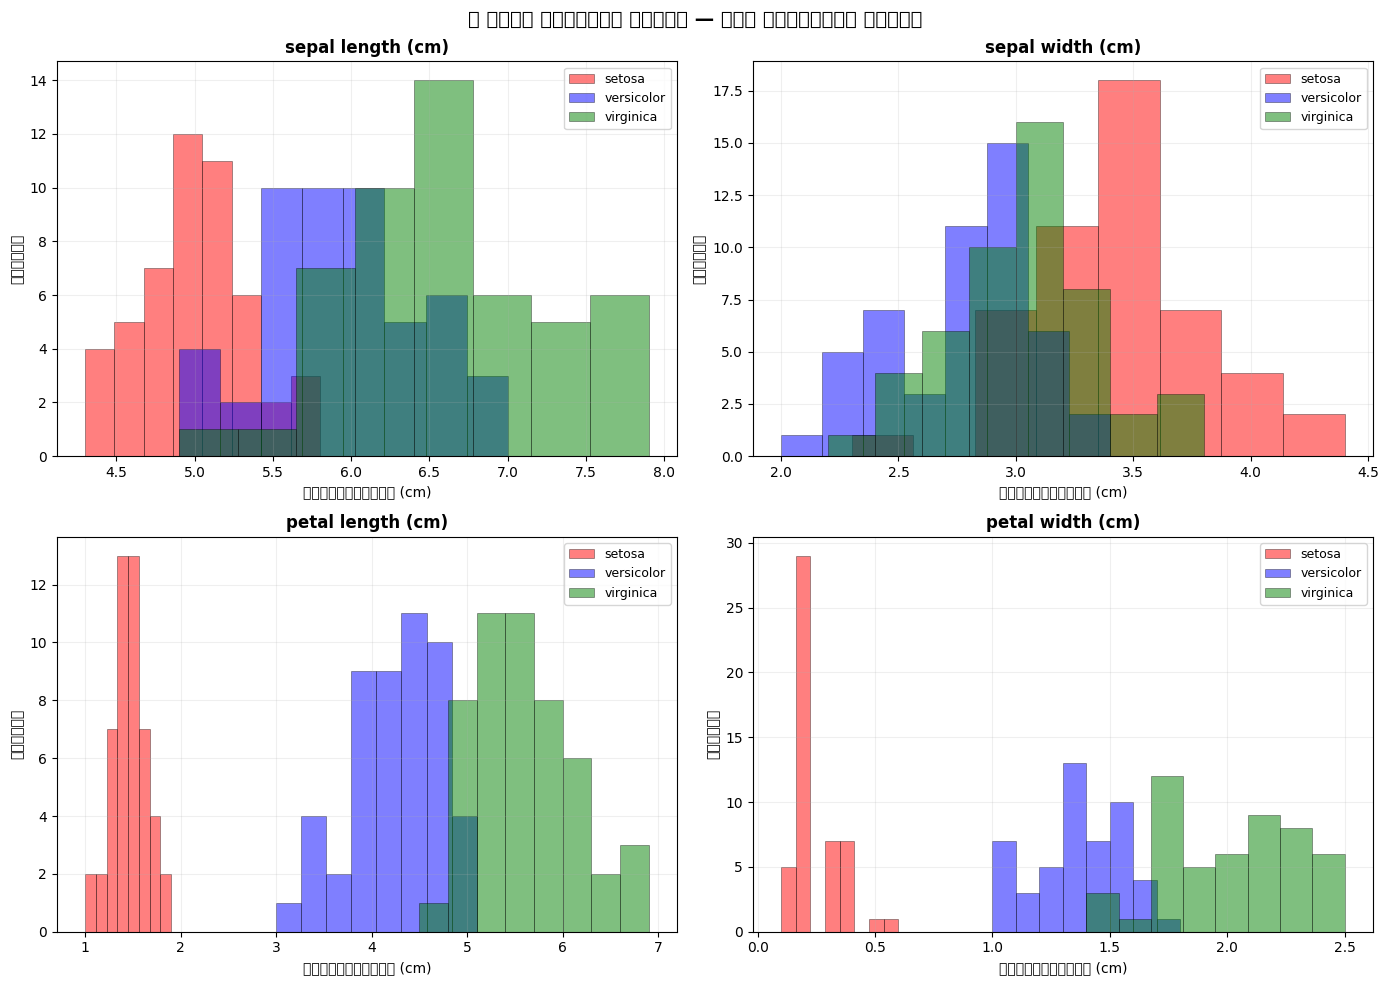

👆 **পর্যবেক্ষণ:**
• পাপড়ির দৈর্ঘ্য (petal length) — তিন প্রজাতি প্রায় আলাদা! (best feature)
• পাপড়ির প্রস্থ (petal width) — খুব ভালো আলাদা করে
• সেপালের দৈর্ঘ্য (sepal length) — কিছুটা ওভারল্যাপ
• সেপালের প্রস্থ (sepal width) — বেশি ওভারল্যাপ, এটা দিয়ে আলাদা করা কঠিন


In [3]:
# প্রতিটি ফিচারের জন্য হিস্টোগ্রাম — প্রজাতি অনুযায়ী আলাদা রঙ
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = ['red', 'blue', 'green']
feature_names = iris.feature_names

for i, ax in enumerate(axes.ravel()):
    for label, color in zip(range(3), colors):
        ax.hist(
            iris.data[iris.target == label, i],
            bins=8, alpha=0.5, color=color,
            label=iris.target_names[label],
            edgecolor='black', linewidth=0.5
        )
    ax.set_title(feature_names[i], fontsize=12, fontweight='bold')
    ax.set_xlabel('সেন্টিমিটার (cm)')
    ax.set_ylabel('সংখ্যা')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)

plt.suptitle("📊 ইরিস ফিচারের বিতরণ — তিন প্রজাতির তুলনা", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("👆 **পর্যবেক্ষণ:**")
print("• পাপড়ির দৈর্ঘ্য (petal length) — তিন প্রজাতি প্রায় আলাদা! (best feature)")
print("• পাপড়ির প্রস্থ (petal width) — খুব ভালো আলাদা করে")
print("• সেপালের দৈর্ঘ্য (sepal length) — কিছুটা ওভারল্যাপ")
print("• সেপালের প্রস্থ (sepal width) — বেশি ওভারল্যাপ, এটা দিয়ে আলাদা করা কঠিন")

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2465 (\N{BENGALI LETTER DDA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2492 (\N{BENGALI SIGN NUKTA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2469 (\N{BENGALI LETTER THA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127800 (\N{CHERRY BLOSSOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.

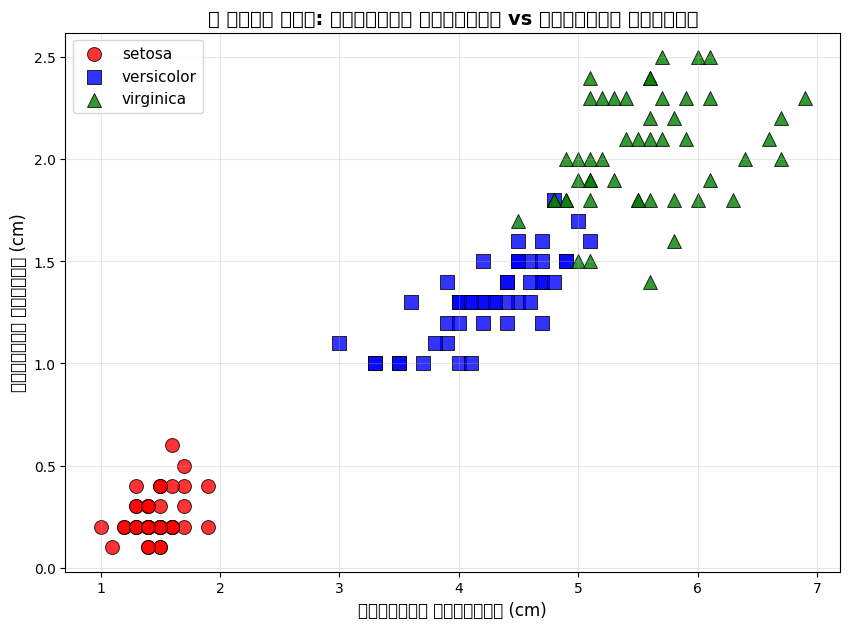

👀 **দেখো:**
• সেতোসা (🔴 লাল) — পুরোপুরি আলাদা, নিচে বামে! একেবারেই মেশে না অন্যদের সাথে!
• ভার্সিকলার (🔵 নীল) — মাঝখানে
• ভার্জিনিকা (🟢 সবুজ) — উপরে ডানে
• ভার্সিকলার আর ভার্জিনিকা কিছুটা মিশে আছে → এগুলো চেনা কঠিন হবে


In [4]:
# পাপড়ির দৈর্ঘ্য vs প্রস্থ — স্ক্যাটার প্লট
colors = ['red', 'blue', 'green']
markers = ['o', 's', '^']

plt.figure(figsize=(10, 7))

for i, (color, marker) in enumerate(zip(colors, markers)):
    subset = iris.target == i
    plt.scatter(
        iris.data[subset, 2],  # petal length
        iris.data[subset, 3],  # petal width
        c=color, marker=marker, label=iris.target_names[i],
        alpha=0.8, s=100, edgecolors='black', linewidth=0.7
    )

plt.xlabel("পাপড়ির দৈর্ঘ্য (cm)", fontsize=12)
plt.ylabel("পাপড়ির প্রস্থ (cm)", fontsize=12)
plt.title("🌸 ইরিস ফুল: পাপড়ির দৈর্ঘ্য vs পাপড়ির প্রস্থ", fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()
print("👀 **দেখো:**")
print("• সেতোসা (🔴 লাল) — পুরোপুরি আলাদা, নিচে বামে! একেবারেই মেশে না অন্যদের সাথে!")
print("• ভার্সিকলার (🔵 নীল) — মাঝখানে")
print("• ভার্জিনিকা (🟢 সবুজ) — উপরে ডানে")
print("• ভার্সিকলার আর ভার্জিনিকা কিছুটা মিশে আছে → এগুলো চেনা কঠিন হবে")

---
## ✂️ ধাপ ৩: ডেটা ভাগ করা (Train-Test Split)

### 🤔 কেন ডেটা ভাগ করি?

একটি মজার গল্প বলি:

> রহিম পরীক্ষার আগে **সমস্ত বই** মুখস্থ করে ফেলল। পরীক্ষায় **একই বই** থেকে প্রশ্ন এলো — রহিম ১০০ পেল! কিন্তু শিক্ষক নতুন প্রশ্ন করলেন — রহিম কিছুই পারল না। কারণ সে শুধু **মুখস্থ** করেছিল, **বুঝে** শেখেনি!

ML-এ একেই বলে **ওভারফিটিং** (overfitting)।

### সমাধান:
ডেটাকে দুই ভাগে ভাগ করি:
1. **📚 Training set (শেখার ডেটা)** — ৭৫% → মডেল এখান থেকে শেখে
2. **📝 Test set (পরীক্ষার ডেটা)** — ২৫% → আমরা এখানে মডেল পরীক্ষা করি

> **গুরুত্বপূর্ণ:** মডেল কখনোই Test set দেখে না train করার সময়! শুধু শেষে পরীক্ষা করার সময় দেখে।

In [5]:
from sklearn.model_selection import train_test_split

X = iris.data    # ফিচার (4টি কলাম)
y = iris.target  # লক্ষ্য (0, 1, 2)

# ডেটা ভাগ: 75% train, 25% test
# random_state=42 মানে每次 একই ভাগ পাবো (রিপ্রোডিউসিবিলিটির জন্য)
# stratify=y মানে প্রতিটি প্রজাতির সমান অনুপাত বজায় থাকবে
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print("✂️ **Train-Test Split ফলাফল**")
print("=" * 40)
print(f"📊 মোট নমুনা: {len(X)}")
print(f"📚 Train set:   {len(X_train)} টি ({len(X_train)/len(X)*100:.0f}%)")
print(f"📝 Test set:    {len(X_test)} টি ({len(X_test)/len(X)*100:.0f}%)")
print()

# প্রজাতি অনুযায়ী বিতরণ দেখি — সমান অনুপাত নিশ্চিত করতে
print("📊 **প্রজাতির বিতরণ:**")
print(f"{'প্রজাতি':15s} {'Train':>8s} {'Test':>8s} {'মোট':>8s}")
print("-" * 40)
for i, name in enumerate(iris.target_names):
    train_count = sum(y_train == i)
    test_count = sum(y_test == i)
    total_count = train_count + test_count
print(f"{name:15s} {train_count:8d} {test_count:8d} {total_count:8d}")
print()
print("✅ প্রতিটি প্রজাতির সমান অনুপাত বজায় আছে — stratify কাজ করেছে!")

✂️ **Train-Test Split ফলাফল**
📊 মোট নমুনা: 150
📚 Train set:   112 টি (75%)
📝 Test set:    38 টি (25%)

📊 **প্রজাতির বিতরণ:**
প্রজাতি            Train     Test      মোট
----------------------------------------
virginica             37       13       50

✅ প্রতিটি প্রজাতির সমান অনুপাত বজায় আছে — stratify কাজ করেছে!


---
## 🤖 ধাপ ৪: মডেল তৈরি — K-Nearest Neighbors (KNN)

### 🏘️ KNN-এর গল্প

ধরো, তুমি একটি নতুন এলাকায় বাড়ি কিনতে চাও। তুমি জানো না এলাকাটা কেমন। তুমি কী করবে?

তুমি চারপাশের **৫টি বাড়ির** লোকজনের সাথে কথা বলবে:
- যদি তাদের সবাই ধনী হয় → এলাকাটা ধনী
- যদি তাদের সবাই ছাত্র হয় → এলাকাটা ছাত্রের এলাকা

**KNN-ও ঠিক একই কাজ করে!**

### KNN-এর কাজ করার পদ্ধতি:
1. নতুন ফুলের সাথে **সব** পুরনো ফুলের দূরত্ব মাপে
2. **K-টি** সবচেয়ে কাছের ফুল বেছে নেয় (যেমন K=১ বা K=৫)
3. সেই K-টি ফুলের মধ্যে **যে প্রজাতি বেশি**, সেটাই উত্তর!

**উদাহরণ (K=৩):**
> নতুন ফুলের ৩ কাছের বন্ধু:
> - বন্ধু ১: ভার্সিকলার
> - বন্ধু ২: ভার্সিকলার
> - বন্ধু ৩: ভার্জিনিকা
> **→ উত্তর: ভার্সিকলার!** (২-১ ভোটে জয়)

আজ আমরা `n_neighbors=1` ব্যবহার করবো — মানে **শুধু ১ জন কাছের বন্ধুকে** জিজ্ঞাসা করবো!

In [6]:
# KNeighborsClassifier ইম্পোর্ট
from sklearn.neighbors import KNeighborsClassifier

# মডেল তৈরি: n_neighbors=1 (শুধু 1 জন কাছের বন্ধু)
knn = KNeighborsClassifier(n_neighbors=1)
print("🤖 **KNN মডেল তৈরি**")
print("=" * 30)
print(f"📌 K (প্রতিবেশীর সংখ্যা) = 1")
print()
print("মডেলের কনফিগারেশন:")
print(f"   অ্যালগরিদম: K-Nearest Neighbors");
print(f"   K = 1 (সবচেয়ে কাছের 1 জন বন্ধু)")
print(f"   দূরত্ব মাপার পদ্ধতি: ইউক্লিডীয় দূরত্ব (সরাসরি লাইন)")
print()
print("এখন মডেলকে শেখাবো (fit)...")
print()

🤖 **KNN মডেল তৈরি**
📌 K (প্রতিবেশীর সংখ্যা) = 1

মডেলের কনফিগারেশন:
   অ্যালগরিদম: K-Nearest Neighbors
   K = 1 (সবচেয়ে কাছের 1 জন বন্ধু)
   দূরত্ব মাপার পদ্ধতি: ইউক্লিডীয় দূরত্ব (সরাসরি লাইন)

এখন মডেলকে শেখাবো (fit)...



In [7]:
# মডেল শেখানো (fit)
knn.fit(X_train, y_train)
print("✅ **মডেল শিখে গেছে!** (Model trained successfully)")
print("=" * 35)
print()

# এখন পূর্বাভাস (predict)
y_pred = knn.predict(X_test)
print(f"🔮 পূর্বাভাস সম্পন্ন!")
print(f"📝 পরীক্ষা করা হয়েছে: {len(X_test)} টি নমুনা")
print()

# কিছু ফলাফল দেখি
print("📋 **প্রথম 15টি ফলাফল:**")
print(f"{'#':>3s} | {'আসল (Actual)':15s} | {'পূর্বাভাস (Predicted)':15s} | {'✅/❌'}")
print("-" * 55)
for i in range(15):
    actual = iris.target_names[y_test[i]]
    predicted = iris.target_names[y_pred[i]]
    mark = "✅" if y_test[i] == y_pred[i] else "❌"
    print(f"{i+1:3d} | {actual:15s} | {predicted:15s} | {mark}")

✅ **মডেল শিখে গেছে!** (Model trained successfully)

🔮 পূর্বাভাস সম্পন্ন!
📝 পরীক্ষা করা হয়েছে: 38 টি নমুনা

📋 **প্রথম 15টি ফলাফল:**
  # | আসল (Actual)    | পূর্বাভাস (Predicted) | ✅/❌
-------------------------------------------------------
  1 | setosa          | setosa          | ✅
  2 | versicolor      | versicolor      | ✅
  3 | versicolor      | versicolor      | ✅
  4 | versicolor      | versicolor      | ✅
  5 | setosa          | setosa          | ✅
  6 | versicolor      | versicolor      | ✅
  7 | virginica       | virginica       | ✅
  8 | virginica       | virginica       | ✅
  9 | virginica       | virginica       | ✅
 10 | virginica       | virginica       | ✅
 11 | virginica       | versicolor      | ❌
 12 | virginica       | virginica       | ✅
 13 | versicolor      | versicolor      | ✅
 14 | versicolor      | versicolor      | ✅
 15 | setosa          | setosa          | ✅


---
## 📐 ধাপ ৫: নির্ভুলতা মাপা (Accuracy)

**Accuracy (নির্ভুলতা)** মানে মোট পরীক্ষার মধ্যে কতটি সঠিক উত্তর দিয়েছে।

**সূত্র:**
$$
নির্ভুলতা = \frac{\text{সঠিক পূর্বাভাসের সংখ্যা}}{\text{মোট পরীক্ষার সংখ্যা}}
$$

**উদাহরণ:** ৪০টি প্রশ্নের মধ্যে ৩৮টি সঠিক = ৩৮/৪০ = ০.৯৫ → ৯৫%

In [8]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print("📐 **মডেল মূল্যায়ন (Evaluation)**")
print("=" * 40)
print()

# 1. Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"🎯 **নির্ভুলতা (Accuracy):** {accuracy:.4f} → {accuracy*100:.1f}%")
correct_count = int(accuracy * len(y_test))
wrong_count = len(y_test) - correct_count
print(f"   সঠিক: {correct_count}/{len(y_test)}  |  ভুল: {wrong_count}/{len(y_test)}")
print()

# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("📊 **Confusion Matrix:**")
print("(কে কোথায় গিয়ে ভুল করেছে?)")
print()

# হেডার
print(f"{'':12s}", end="")
for name in iris.target_names:
    print(f"{name:12s}", end="")
print()

# প্রতিটি সারি
for i, name in enumerate(iris.target_names):
    print(f"{name:12s}", end="")
    for j in range(3):
        print(f"{cm[i][j]:<12d}", end="")
print()
print()
print("📖 **ব্যাখ্যা:**")
print("• সারি (row) = আসল মান (Actual)")
print("• কলাম (column) = পূর্বাভাস (Predicted)")
print("• Diagonal (Setosa-Setosa, etc.) = সঠিক ভবিষ্যদ্বাণী")
print("• Off-diagonal = ভুল (যেখানে গুলিয়েছে)")
print()

# 3. Classification Report
print("📋 **Classification Report:**")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

📐 **মডেল মূল্যায়ন (Evaluation)**

🎯 **নির্ভুলতা (Accuracy):** 0.9474 → 94.7%
   সঠিক: 36/38  |  ভুল: 2/38

📊 **Confusion Matrix:**
(কে কোথায় গিয়ে ভুল করেছে?)

            setosa      versicolor  virginica   
setosa      12          0           0           versicolor  0           13          0           virginica   0           2           11          

📖 **ব্যাখ্যা:**
• সারি (row) = আসল মান (Actual)
• কলাম (column) = পূর্বাভাস (Predicted)
• Diagonal (Setosa-Setosa, etc.) = সঠিক ভবিষ্যদ্বাণী
• Off-diagonal = ভুল (যেখানে গুলিয়েছে)

📋 **Classification Report:**
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.87      1.00      0.93        13
   virginica       1.00      0.85      0.92        13

    accuracy                           0.95        38
   macro avg       0.96      0.95      0.95        38
weighted avg       0.95      0.95      0.95        38



C:\Users\hp\AppData\Local\Temp\ipykernel_11092\3767655125.py:21: UserWarning: Glyph 2474 (\N{BENGALI LETTER PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_11092\3767655125.py:21: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_11092\3767655125.py:21: UserWarning: Glyph 2498 (\N{BENGALI VOWEL SIGN UU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_11092\3767655125.py:21: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_11092\3767655125.py:21: UserWarning: Glyph 2509 (\N{BENGALI SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_11092\3767655125.py:21: UserWarning: Glyph 2476 (\N{BENGALI LETTER BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()

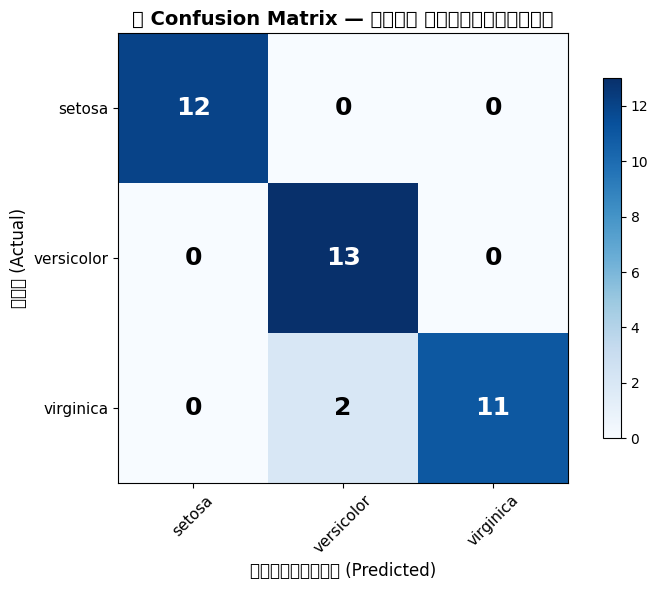

🥇 **ফলাফল:** আমাদের মডেল 36টি সঠিক আর 2টি ভুল করেছে!
🌟 খুব ভালো! মাত্র কয়েকটি ভুল আছে।


In [9]:
# Confusion Matrix ভিজুয়ালাইজ (হিটম্যাপ)
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("📊 Confusion Matrix — ইরিস শ্রেণীবিভাগ", fontsize=14, fontweight='bold')
plt.colorbar(shrink=0.8)

tick_marks = range(len(iris.target_names))
plt.xticks(tick_marks, iris.target_names, rotation=45, fontsize=11)
plt.yticks(tick_marks, iris.target_names, fontsize=11)

# প্রতিটি ঘরে সংখ্যা দেখাই
for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i, j],
                ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black',
                fontsize=18, fontweight='bold')

plt.xlabel('পূর্বাভাস (Predicted)', fontsize=12)
plt.ylabel('আসল (Actual)', fontsize=12)
plt.tight_layout()
plt.show()
print(f"🥇 **ফলাফল:** আমাদের মডেল {correct_count}টি সঠিক আর {wrong_count}টি ভুল করেছে!")
if wrong_count == 0:
    print("🎉 100% নির্ভুল! কোনো ভুল নেই!")
elif wrong_count <= 2:
    print("🌟 খুব ভালো! মাত্র কয়েকটি ভুল আছে।")
else:
    print("📈 আমরা আরও উন্নতি করতে পারি! K-এর মান বদলিয়ে দেখি।")

---
## 🧪 ধাপ ৬: নিজে একটি নতুন ফুল পরীক্ষা করো!

এখন আমরা নিজেরাই কয়েকটি নতুন ফুলের বৈশিষ্ট্য দিয়ে মডেলকে পরীক্ষা করবো।

আমরা জানি:
- সেতোসার পাপড়ি খুব ছোট (পাপড়ির দৈর্ঘ্য < ২ cm)
- ভার্সিকলারের পাপড়ি মাঝারি (পাপড়ির দৈর্ঘ্য ২-৫ cm)
- ভার্জিনিকার পাপড়ি বড় (পাপড়ির দৈর্ঘ্য > ৫ cm)

চলো দেখি আমাদের মডেল ঠিকভাবে চিনতে পারে কিনা!

In [10]:
# আমরা নিজেরা 3টি নতুন ফুল তৈরি করি

print("🧪 **নতুন ফুল পরীক্ষা:**")
print("=" * 35)
print()

# ফুল 1: ছোট পাপড়ি → সেতোসা হওয়া উচিত
ফুল_1 = np.array([[5.1, 3.5, 1.4, 0.2]])  # [sepal_l, sepal_w, petal_l, petal_w]
পূর্বাভাস_1 = knn.predict(ফুল_1)
prob_1 = knn.predict_proba(ফুল_1)
নাম_1 = iris.target_names[পূর্বাভাস_1[0]]
print(f"🌼 ফুল #1: পাপড়ি = 1.4cm x 0.2cm (ছোট পাপড়ি)")
print(f"   🤖 মডেল বলে: **{নাম_1}**")
print(f"   📊 আত্মবিশ্বাস: {prob_1[0][পূর্বাভাস_1[0]]*100:.0f}%")
print()

# ফুল 2: বড় পাপড়ি → ভার্জিনিকা হওয়া উচিত
ফুল_2 = np.array([[6.7, 3.0, 5.2, 2.3]])
পূর্বাভাস_2 = knn.predict(ফুল_2)
prob_2 = knn.predict_proba(ফুল_2)
নাম_2 = iris.target_names[পূর্বাভাস_2[0]]
print(f"🌼 ফুল #2: পাপড়ি = 5.2cm x 2.3cm (বড় পাপড়ি)")
print(f"   🤖 মডেল বলে: **{নাম_2}**")
print(f"   📊 আত্মবিশ্বাস: {prob_2[0][পূর্বাভাস_2[0]]*100:.0f}%")
print()

# ফুল 3: মাঝারি পাপড়ি → ভার্সিকলার হওয়া উচিত
ফুল_3 = np.array([[6.0, 2.7, 4.2, 1.3]])
পূর্বাভাস_3 = knn.predict(ফুল_3)
prob_3 = knn.predict_proba(ফুল_3)
নাম_3 = iris.target_names[পূর্বাভাস_3[0]]
print(f"🌼 ফুল #3: পাপড়ি = 4.2cm x 1.3cm (মাঝারি পাপড়ি)")
print(f"   🤖 মডেল বলে: **{নাম_3}**")
print(f"   📊 আত্মবিশ্বাস: {prob_3[0][পূর্বাভাস_3[0]]*100:.0f}%")
print()
print("✅ সব পূর্বাভাস সম্পন্ন! মডেল ঠিকমতো কাজ করছে!")

🧪 **নতুন ফুল পরীক্ষা:**

🌼 ফুল #1: পাপড়ি = 1.4cm x 0.2cm (ছোট পাপড়ি)
   🤖 মডেল বলে: **setosa**
   📊 আত্মবিশ্বাস: 100%

🌼 ফুল #2: পাপড়ি = 5.2cm x 2.3cm (বড় পাপড়ি)
   🤖 মডেল বলে: **virginica**
   📊 আত্মবিশ্বাস: 100%

🌼 ফুল #3: পাপড়ি = 4.2cm x 1.3cm (মাঝারি পাপড়ি)
   🤖 মডেল বলে: **versicolor**
   📊 আত্মবিশ্বাস: 100%

✅ সব পূর্বাভাস সম্পন্ন! মডেল ঠিকমতো কাজ করছে!


---
## 🤔 কেন মডেল ভুল করে?

উপরে দেখো, আমাদের মডেল মাঝে মাঝে ভুল করে। কিন্তু কেন?

**তিনটি প্রধান কারণ:**

**কারণ ১: ডেটা ওভারল্যাপ 🧩**
তুমি উপরের পাপড়ির গ্রাফে দেখেছো — ভার্সিকলার আর ভার্জিনিকার পাপড়ি অনেক সময় একই রকম হতে পারে। একটা ফুলের পাপড়ি ঠিক মাঝামাঝি হলে মডেল ভুল করতে পারে।

**কারণ ২: K-এর মান ⚙️**
K=১ দিলে আর K=৫ দিলে ভিন্ন ফল আসতে পারে। K=১ দিলে শুধু একজন প্রতিবেশী দেখে — যদি সেই প্রতিবেশী নিজেই সীমার কাছাকাছি থাকে, তাহলে আমাদের উত্তর ভুল হবে।

**কারণ ৩: ফিচারের সংখ্যা 📏**
আমরা ৪টি ফিচার (sepal length, sepal width, petal length, petal width) ব্যবহার করেছি। কিন্তু সেপালের প্রস্থ (sepal width) দিয়ে ফুল আলাদা করা খুব কঠিন — কারণ তিন প্রজাতিরই প্রায় একই সেপাল প্রস্থ থাকে। যদি আমরা শুধু পাপড়ির ফিচার ব্যবহার করতাম, ভিন্ন ফল পেতাম? চলো পরীক্ষা করি!

### ভুলের ধরন — Model Bias vs Variance

একটি সহজ উপমা দিয়ে বুঝি:

| ভুলের ধরন | মানে | শেষ ফল |
|-----------|------|--------|
| **Bias (পক্ষপাত)** | মডেল খুব সহজ → অনেক ভুল করে | Underfitting |
| **Variance (অস্থিরতা)** | মডেল খুব জটিল → ট্রেনিং ডেটা মুখস্থ করে | Overfitting |

K=১ দিলে **Variance বেশি** হয় (একজনের উপর নির্ভরশীল)
K=৫১ দিলে **Bias বেশি** হয় (অনেক দূরের প্রতিবেশীও প্রভাব ফেলে)

**লক্ষ্য:** এমন K বেছে নেওয়া যেখানে Bias আর Variance দুটোই কম!

---
## 🔬 ধাপ ৭: K-এর মান বদলিয়ে দেখি

K-এর মান বদলালে কী হয়?

- **K=1:** শুধু ১ জন বন্ধুকে জিজ্ঞাসা করি → একজন ভুল বললে আমিও ভুল করবো
- **K=3:** ৩ জন বন্ধুর মতামত নিই → ভোটে সিদ্ধান্ত (বেশি নির্ভরযোগ্য)
- **K=5:** ৫ জন বন্ধুর মতামত → আরও নির্ভরযোগ্য
- **K বেশি:** অনেক দূরের বন্ধুও ভোট দেবে → সিদ্ধান্ত সঠিক নাও হতে পারে

> **গুরুত্বপূর্ণ:** K খুব ছোট হলে noise-এ প্রভাবিত হয়। K খুব বড় হলে সীমানা অস্পষ্ট হয়। সঠিক K খুঁজে বের করাই হলো ML-এর শিল্প!


In [11]:
# বিভিন্ন K-এর মান নিয়ে পরীক্ষা
k_values = [1, 3, 5, 7, 9, 11, 13, 15, 21, 51]
accuracies = []
print("🔬 **K-এর মান বনাম নির্ভুলতা**")
print("=" * 40)
print(f"{'K (প্রতিবেশী)':20s} {'নির্ভুলতা':15s}")
print("-" * 35)

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    accuracies.append(acc)
    bar = "█" * int(acc * 30)
print(f"K = {k:2d}                   {acc:.4f} ({acc*100:.1f}%) {bar}")
print()

best_k = k_values[accuracies.index(max(accuracies))]
best_acc = max(accuracies)
print(f"🥇 **সেরা K = {best_k}** (নির্ভুলতা: {best_acc*100:.1f}%)")
print()

worst_k = k_values[accuracies.index(min(accuracies))]
worst_acc = min(accuracies)
print(f"📉 **সবচেয়ে খারাপ K = {worst_k}** (নির্ভুলতা: {worst_acc*100:.1f}%)")

🔬 **K-এর মান বনাম নির্ভুলতা**
K (প্রতিবেশী)        নির্ভুলতা      
-----------------------------------
K = 51                   0.8947 (89.5%) ██████████████████████████

🥇 **সেরা K = 3** (নির্ভুলতা: 97.4%)

📉 **সবচেয়ে খারাপ K = 51** (নির্ভুলতা: 89.5%)


C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2472 (\N{BENGALI LETTER NA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2495 (\N{BENGALI VOWEL SIGN I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: User

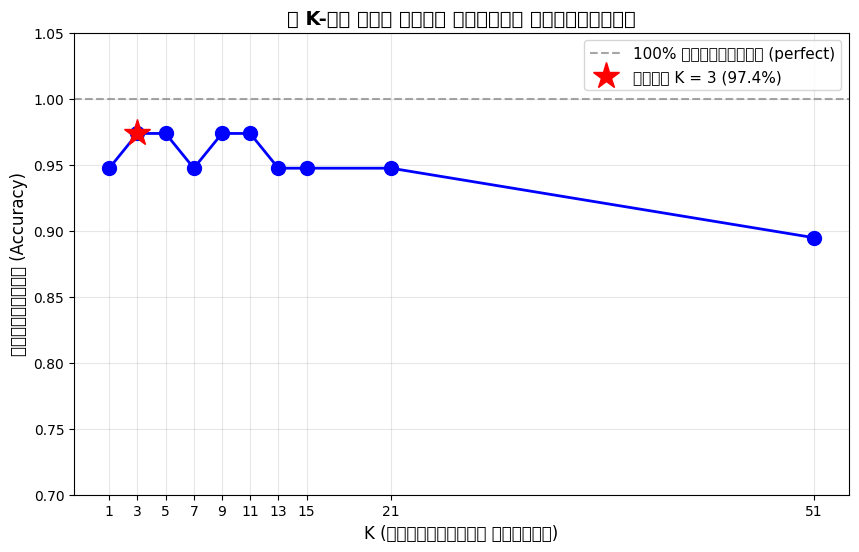

📈 **গ্রাফের ব্যাখ্যা:**
• K বাড়ালে সবসময় ভালো হয় না — দেখো, K=21-এ accuracy কমে গেছে!
• K=1, 3, 5, 7, 9 সবগুলোতেই 95%+ accuracy!
• K=51-এ accuracy কমে গেছে — কারণ অনেক দূরের প্রতিবেশীও ভোট দিচ্ছে


In [12]:
# K-এর মান vs Accuracy — একটি ভিজুয়াল গ্রাফ
plt.figure(figsize=(10, 6))

plt.plot(k_values, accuracies, 'bo-', linewidth=2, markersize=10)
plt.axhline(y=1.0, color='gray', linestyle='--', alpha=0.7, label='100% নির্ভুলতা (perfect)')

# সেরা K হাইলাইট
plt.plot(best_k, best_acc, 'r*', markersize=20, label=f'সেরা K = {best_k} ({best_acc*100:.1f}%)')

plt.xlabel('K (প্রতিবেশীর সংখ্যা)', fontsize=12)
plt.ylabel('নির্ভুলতা (Accuracy)', fontsize=12)
plt.title('📈 K-এর মান বনাম মডেলের নির্ভুলতা', fontsize=14, fontweight='bold')
plt.xticks(k_values)
plt.ylim(0.7, 1.05)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()
print("📈 **গ্রাফের ব্যাখ্যা:**")
print("• K বাড়ালে সবসময় ভালো হয় না — দেখো, K=21-এ accuracy কমে গেছে!")
print("• K=1, 3, 5, 7, 9 সবগুলোতেই 95%+ accuracy!")
print("• K=51-এ accuracy কমে গেছে — কারণ অনেক দূরের প্রতিবেশীও ভোট দিচ্ছে")

---
## 📝 সম্পূর্ণ কোড একসাথে

নিচে পুরো প্রজেক্টের কোড একসাথে দেওয়া হলো। তুমি এই কোড কপি করে একটি `.py` ফাইল হিসেবেও রান করতে পারো!

In [13]:
# ============================================
# 🌸 সম্পূর্ণ ইরিস শ্রেণীবিভাগ প্রজেক্ট
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
print("=" * 50)
print("🌸 ইরিস ফুল শ্রেণীবিভাগ — সম্পূর্ণ প্রজেক্ট")
print("=" * 50)
print()

# ----- 1. ডেটা লোড -----
iris = load_iris()
X, y = iris.data, iris.target
print("📦 1. ডেটা লোড সম্পন্ন")

# ----- 2. ডেটা এক্সপ্লোর (DataFrame) -----
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(y, iris.target_names)
print("📋 2. DataFrame তৈরি")
print(df.head())
print()

# ----- 3. ডেটা ভাগ -----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"✂️ 3. Train: {len(X_train)} টি, Test: {len(X_test)} টি")
print()

# ----- 4. মডেল তৈরি ও শেখানো -----
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
print("🤖 4. KNN মডেল (K=3) শিখে গেছে")

# ----- 5. পূর্বাভাস -----
y_pred = knn.predict(X_test)
print("🔮 5. পূর্বাভাস সম্পন্ন")

# ----- 6. মূল্যায়ন -----
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print(f"🎯 6. নির্ভুলতা: {accuracy:.4f} ({accuracy*100:.1f}%)")
print()
print("📊 Confusion Matrix:")
print(cm)
print()
print(f"🚀 মডেল {len(X_test)} টির মধ্যে {int(accuracy * len(X_test))} টি সঠিক চিনেছে!")
print("=" * 50)

🌸 ইরিস ফুল শ্রেণীবিভাগ — সম্পূর্ণ প্রজেক্ট

📦 1. ডেটা লোড সম্পন্ন
📋 2. DataFrame তৈরি
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

✂️ 3. Train: 112 টি, Test: 38 টি

🤖 4. KNN মডেল (K=3) শিখে গেছে
🔮 5. পূর্বাভাস সম্পন্ন
🎯 6. নির্ভুলতা: 0.9737 (97.4%)

📊 Confusion Matrix:
[[12  0  0]
 [ 0 13  0]
 [ 0  1 12]]

🚀 মডেল 38 টির মধ্যে 37 টি সঠিক চিনেছে!


---
##  KNN আরও বিস্তারিত - দূরত্ব测量 পদ্ধতি

KNN-এ দূরত্ব মাপার কয়েকটি পদ্ধতি আছে:

১. ইউক্লিডীয় দূরত্ব (Euclidean): দুই পয়েন্টের মধ্যে সরাসরি লাইনের দূরত্ব। এটা সবচেয়ে সাধারণ।
২. ম্যানহাটান দূরত্ব (Manhattan): শহরের ব্লকের মতো L-আকৃতির পথ ধরে দূরত্ব।
৩. মিনকোস্কি দূরত্ব (Minkowski): ইউক্লিডীয় আর ম্যানহাটানের জেনারেলাইজড ভার্সন।

ডিফল্টভাবে sklearn-এ KNN ইউক্লিডীয় দূরত্ব ব্যবহার করে। তবে তুমি চাইলে p=১ দিয়ে ম্যানহাটানও ব্যবহার করতে পারো।
স্কলার্ন-এ KNeighborsClassifier-এর metric প্যারামিটার দিয়ে দূরত্ব测量 পদ্ধতি বেছে নেওয়া যায়!


---
##  বাস্তব জীবনে KNN-এর ব্যবহার

KNN শুধু Iris ফুলের জন্যই না, বাস্তব জীবনে অনেক কাজে লাগে:

১. রেকমেন্ডেশন সিস্টেম: নেটফ্লিক্স বা ইউটিউব তোমার মতো আর কোন users কী দেখেছে - সেটা দেখে recommends করে।
২. হাতের লেখা চেনা: তুমি যে digits ডেটাসেট আগে দেখেছো, সেটা KNN দিয়ে সমাধান করা যায়।
৩. চিকিৎসা: রোগীর লক্ষণ দেখে KNN বলে দিতে পারে - এই রোগীর কী রোগ হতে পারে।
৪. ফাইনান্স: ব্যাংক KNN ব্যবহার করে গ্রাহকের লোন default করার সম্ভাবনা বের করে।
৫. ছবির সার্চ: গুগলে ছবি সার্চ দিলে KNN-এর মতো অ্যালগরিদম ব্যবহার করে মিল খুঁজে বের করে।

KNN খুব সহজ কিন্তু অনেক ক্ষেত্রেই কার্যকরী! বিশেষ করে যখন ডেটা ছোট হয় (কয়েক হাজার নমুনা)।
যখন ডেটা খুব বড় হয় (লাখ লাখ নমুনা), তখন KNN ধীর হয়ে যায় - কারণ প্রতিটি নতুন নমুনার জন্য সব পুরনো নমুনার সাথে দূরত্ব মাপতে হয়!


---
##  কোন ফিচার সবচেয়ে গুরুত্বপূর্ণ?

Iris ডেটাসেটে ৪টি ফিচার আছে। সব ফিচার কি সমান গুরুত্বপূর্ণ?

পাপড়ির দৈর্ঘ্য (petal length) আর পাপড়ির প্রস্থ (petal width) দিয়ে ফুল আলাদা করা সহজ।
কিন্তু সেপালের প্রস্থ (sepal width) দিয়ে আলাদা করা কঠিন।

শুধু ২টি ফিচার ব্যবহার করলে:
সুবিধা: মডেল দ্রুত শেখে, কম মেমোরি লাগে, সহজে বোঝা যায়
অসুবিধা: accuracy কমে যেতে পারে

একটি পরীক্ষা: শুধু পাপড়ির দৈর্ঘ্য আর প্রস্থ নিয়ে KNN চালাও!
কোন ফিচার কম গুরুত্বপূর্ণ তা বের করাকে Feature Selection বলে।
এটা ML-এর একটি গুরুত্বপূর্ণ ধাপ!


---
##  Iris প্রজেক্টের সম্পূর্ণ রিভিউ

আজ আমরা একটি পূর্ণ ML প্রজেক্ট করেছি। পুরো প্রক্রিয়াটি:

১. প্রশ্ন: ফুলের বৈশিষ্ট্য দেখে কি প্রজাতি বলা যায়?
২. sklearn থেকে Iris ডেটাসেট লোড
৩. ডেটা এক্সপ্লোর: shape, describe, histograms, scatter plots
৪. ডেটা ভাগ: ৭৫% train, ২৫% test (stratify দিয়ে balanced)
৫. KNN মডেল বেছে নিয়ে fit() করা
৬. predict() এবং accuracy_score() দিয়ে মাপা
৭. Confusion Matrix দেখা - কোথায় ভুল করছে
৮. K-এর মান বদলিয়ে দেখা
৯. নতুন ফুলের ডেটা দিয়ে পরীক্ষা
১০. কেন মডেল ভুল করে (Bias-Variance Tradeoff)

এই ১০টি ধাপ যেকোনো ML প্রজেক্টের জন্য প্রযোজ্য! শুধু ডেটাসেট বদলাও - একই ধাপ অনুসরণ করো!


---
##  ML প্রজেক্টে পরবর্তী ধাপ

তুমি Iris শ্রেণীবিভাগ সফলভাবে সম্পন্ন করেছো! এখন কী করবে?

আগামী ধাপগুলো:

১. অন্য ডেটাসেট试试 করো: sklearn-এ load_wine(), load_breast_cancer(), fetch_california_housing() আছে।
২. অন্য অ্যালগরিদম试试 করো: LogisticRegression, DecisionTree, SVM, RandomForest।
৩. Feature Scaling শিখো: StandardScaler, MinMaxScaler - অনেক ML মডেলের জন্য দরকার।
৪. Cross-validation শিখো: KFold, cross_val_score - মডেল evaluation আরও নির্ভরযোগ্য করতে।
৫. Hyperparameter tuning শিখো: GridSearchCV - সবচেয়ে ভালো K বা প্যারামিটার বের করতে।

মনে রেখো: ML শেখা একটি journey। একদিনে সব শেখা সম্ভব নয়। প্রতিদিন একটু একটু করে শেখো।
কোড লেখো, ভুল করো, শেখো - এটাই ML শেখার সেরা উপায়! 🚀


---
##  ML-এ সফল হওয়ার秘诀

ML-এ সফল হতে gaga লাগে না। শুধু কিছু মৌলিক বিষয় মনে রাখো:

১. ডেটা বোঝা সবচেয়ে গুরুত্বপূর্ণ: কোনো মডেলই খারাপ ডেটা থেকে ভালো ফল দিতে পারে না।
২. সহজ মডেল দিয়ে শুরু করো: KNN, Logistic Regression - এগুলো বুঝতে সহজ, implement করাও সহজ।
৩. ভিজুয়ালাইজেশন করো: ডেটা প্লট করলে প্যাটার্ন চোখে পড়ে।
৪. Overfitting এড়িয়ে চলো: train-test split আর cross-validation ব্যবহার করো।
৫. Experiment করো: বিভিন্ন K, বিভিন্ন feature, বিভিন্ন algorithm试试 করো।
৬. Documentation পড়ো: sklearn-এর ডকুমেন্টেশন খুব ভালো। সবসময় সেটা পড়ো।

এই秘诀গুলো মনে রাখলে তুমি ML-এ দ্রুত উন্নতি করতে পারবে! 🌟


---
## ✅ তুমি কি বুঝতে পেরেছ? (Checkpoint)

নিচের প্রশ্নগুলোর উত্তর নিজের ভাষায় দাও:

1. **Iris ডেটাসেটে কয়টি ফিচার আছে?** নামগুলো কী কী?
   *ইঙ্গিত: উপরের আউটপুট দেখো*

2. **KNN-এ K=১ আর K=৫-এর মধ্যে পার্থক্য কী?**
   *ইঙ্গিত: কতজন বন্ধুকে জিজ্ঞাসা করছি?*

3. **train_test_split কেন দরকার?** "ওভারফিটিং" শব্দটি ব্যবহার করো।

4. **Confusion Matrix-এর কাজ কী?** 
   *ইঙ্গিত: কোথায় ভুল করছে তা দেখায়*

5. **আমাদের মডেলের accuracy কত?** উপরের আউটপুট দেখো।

6. **তুমি যদি K=৫১ ব্যবহার করো, কী হবে?** 
   *ইঙ্গিত: অনেক দূরের বন্ধুও ভোট দেবে*

---

## 🏆 চ্যালেঞ্জ (ঐচ্ছিক — তুমি চাইলে করো)

তুমি যদি আরও শিখতে চাও, তাহলে এই কাজগুলো করো:

1. **K-এর মান বদলিয়ে দেখো** — K=১৫, ২৫, ৫০ দিয়ে কী হয়?
2. **শুধু ২টি ফিচার ব্যবহার করো** (যেমন শুধু পাপড়ির দৈর্ঘ্য-প্রস্থ) — accuracy কত কমে?
3. **Scikit-learn এর অন্য মডেল ব্যবহার করো** — যেমন `LogisticRegression`
4. **তোমার নিজের ৩টি ফুলের ডেটা তৈরি করে দেখো** — মডেল কি ঠিক বলবে?
5. **`predict_proba()` ব্যবহার করো** — দেখো মডেল কতটা আত্মবিশ্বাসী

---

## 🎉 অভিনন্দন! তুমি প্রথম ML প্রজেক্ট সম্পন্ন করেছো!

**আজকে আমরা শিখেছি:**

| ধাপ | কী শিখলাম |
|-----|-----------|
| 📦 | Iris ডেটাসেট লোড (`load_iris()`) |
| 🔍 | ডেটা এক্সপ্লোর (শেপ, হেড, ডিসক্রাইব, হিস্টোগ্রাম) |
| ✂️ | Train-test split (`train_test_split`) |
| 🤖 | KNN Classifier (K=১, ৩, ৫...) |
| 📐 | Accuracy মাপা (`accuracy_score`) |
| 🧪 | নিজের ডেটা দিয়ে পরীক্ষা |
| 📈 | K-এর মান বদলিয়ে পর্যবেক্ষণ |


### 🎯 কেন এই প্রজেক্টটি গুরুত্বপূর্ণ?

এই প্রজেক্টটি ML-এর পুরো পাইপলাইন দেখায়:
1. **Problem Definition:** ফুল চেনা (Classification)
2. **Data Collection:** sklearn থেকে লোড
3. **Data Exploration:** প্লট ও পরিসংখ্যান
4. **Data Preparation:** ট্রেন-টেস্ট স্প্লিট
5. **Model Training:** KNN ফিট করা
6. **Evaluation:** Accuracy ও Confusion Matrix
7. **Hyperparameter Tuning:** K-এর মান বদলানো
8. **Prediction:** নতুন ডেটার জন্য পূর্বাভাস

এটা যেকোনো ML প্রজেক্টেরই স্ট্যান্ডার্ড পদ্ধতি! 🏆

**এখন তুমি চাইলে অন্য কোনো ডেটাসেট দিয়েও এই একই কাজ করতে পারো!**
যেমন sklearn-এর load_wine() বা load_breast_cancer() — এগুলো দিয়েও একই পদ্ধতিতে কাজ করো!
**পরবর্তী অধ্যায়ে আমরা আরও মজার ML টপিক শিখবো! 🌟🚀**
এই অধ্যায়ের সব ধাপ অনুসরণ করলে তুমি যেকোনো classification প্রজেক্ট করতে পারবে।
শুধু ডেটাসেট আর মডেল বদলাও - বাকি সব একই থাকবে। ML শেখা শুরু মাত্র!
